# Web Scraping and Sentiment Analysis Using Newspaper3k

## 1. Introduction  
This document explains the Newspaper3k library, how it extracts online news articles, what operations it performs internally, and how the scraped text is cleaned and analyzed using NLP methods. Newspaper3k is designed specifically for news content and provides an automated, consistent way to collect article text and metadata for tasks such as sentiment analysis, topic modeling, or transformer-based NLP studies.

---

## 2. Newspaper3k: Detailed Overview  
Newspaper3k is a Python library created for automatic extraction of news articles from online sources. News websites contain a large amount of non-article content such as ads, menus, comment sections, sidebars, footers, and scripts. Conventional scraping usually requires manual filtering of such noise, but Newspaper3k isolates the central article body using specialized extraction algorithms.

### Core Functions  
1. **HTML Downloading**  
   Retrieves the full HTML page, handling redirects, compression, and character encodings.

2. **Boilerplate Removal**  
   Removes advertisements, navigation bars, pop-ups, JavaScript content, and other non-essential components, leaving only the main article text.

3. **Metadata Extraction**  
   Automatically extracts:
   - Headline  
   - Authors  
   - Publication date  
   - Keywords from meta tags  
   - Top image  
   - Embedded media  

4. **Article Text Extraction**  
   Identifies and isolates clean textual content without HTML tags or scripts, ensuring that the scraped text is usable directly for NLP tasks.

5. **Language Detection**  
   Detects the article’s language and adjusts internal tokenization rules accordingly.

6. **Built-in NLP Functions (`article.nlp()`)**  
   Provides quick insights using TextRank-based methods:
   - Keyword extraction  
   - Summary generation  
   - Tokenization  
   - Stemming  

7. **Bulk Website Scraping**  
   With `newspaper.build()`, Newspaper3k can crawl entire news sites and extract multiple articles, useful for building datasets from domains like BBC, CNN, Reuters, etc.

### Why Newspaper3k Is Preferred  
Manual scraping using BeautifulSoup or Selenium requires significant custom code to identify article containers, remove unwanted elements, and clean formatting. Newspaper3k solves these issues by providing a ready-made, domain-specific extraction pipeline. This reduces errors, saves time, and ensures consistent results when dealing with different news websites.

### Applications  
- Sentiment analysis  
- Topic modeling and clustering  
- Fake news detection  
- Media bias and framing analysis  
- Building text corpora  
- Event timeline construction  
- Educational NLP experiments  

---

## 3. Explanation of the Code Used  

### Step 1: Library Imports and NLTK Setup  
The script imports Newspaper3k, TextBlob, NLTK, pandas, matplotlib, and WordCloud.  
Stopwords, tokenizers, and WordNet resources are downloaded for text cleaning and lemmatization.

### Step 2: Article Downloading and Parsing  
```python
article = Article(url)
article.download()
article.parse()
article.nlp()


#  News Scraper and Sentiment Analysis

## Overview
This project demonstrates how to **scrape news articles from BBC**, clean the text, perform **sentiment analysis**, and visualize the results using **pie charts and WordClouds**. The workflow is designed for classroom demonstration to show real-world applications of **Natural Language Processing (NLP)**.

---

## 1. Libraries Used

| Library          | Purpose |
|-----------------|---------|
| `newspaper3k`    | Scraping and parsing news articles |
| `nltk`           | Natural Language Processing: tokenization, stopwords, lemmatization |
| `pandas`         | Data manipulation and DataFrame operations |
| `textblob`       | Sentiment analysis (polarity calculation) |
| `matplotlib`     | Visualizing data with charts |
| `wordcloud`      | Generating WordClouds for text visualization |

---

## 2. Steps in the Workflow

### a) Scraping Articles
- A list of BBC news article URLs is provided.
- Each article is downloaded and parsed using `newspaper3k`.
- Headlines, authors, publish dates, and article text are extracted.
- All article texts are combined into a single text corpus.

### b) Cleaning Text
- Convert all text to lowercase.
- Remove numbers, punctuation, and special characters.
- Tokenize text into words.
- Remove common **stopwords** like "the", "is", "and".
- Lemmatize words to their root forms for consistency.

### c) Creating a Words DataFrame
- Split the cleaned text into individual words.
- Store words in a `pandas` DataFrame.
- Useful for further analysis like frequency counts, filtering, etc.

### d) Sentiment Analysis
- The combined text is split into **sentences**.
- Each sentence is analyzed using `TextBlob` to compute **polarity**:
  - **Positive**: polarity > 0.1  
  - **Negative**: polarity < -0.1  
  - **Neutral**: polarity between -0.1 and 0.1
- Sentiment of each sentence is stored in a DataFrame.

### e) Visualization
1. **Sentiment Pie Chart**
   - Displays the proportion of Positive, Neutral, and Negative sentences.
   - Gives a quick overview of the overall sentiment of the articles.
2. **WordCloud**
   - Highlights the most frequent words in the combined text.
   - Provides a visual representation of key topics discussed in the articles.

---

## 3. Output
- **Headlines** of all articles.
- **DataFrame** containing all words in the cleaned text.
- **Sentence-level sentiment table** with polarity and sentiment category.
- **Pie chart** showing overall sentiment distribution.
- **WordCloud** of the combined article text.

---

## 4. Notes
- This approach works for **BBC articles** and can be adapted to other news websites.
- Ensure that `nltk` corpora like `punkt`, `stopwords`, and `wordnet` are downloaded before running the analysis.
- This workflow is suitable for classroom demos to explain **text preprocessing, sentiment analysis, and visualization**.


In [20]:
# Install newspaper3k and required dependencies
!pip install newspaper3k
#!pip install newspaper3k textblob nltk pandas matplotlib
#!pip install nltk
#!pip install pandas
#!pip install matplotlib
#!pip install textblob
#!pip install wordcloud
!pip install lxml_html_clean



In [21]:
import nltk

# Download necessary NLTK packages
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Single Article Scraper

In [22]:
from newspaper import Article
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud


# NLTK setup
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [23]:
 # Load and parse the article
url = "https://www.bbc.com/news/articles/cwy7vrd8k4eo"
article = Article(url)
article.download()
article.parse()
article.nlp()

headline = article.title
authors = article.authors
publish_date = article.publish_date
text = article.text

print("----- Headline -----")
print(headline)
print("\nAuthors:", authors)
print("Publish date:", publish_date)
print("\n----- First 5 lines of raw text -----")
print("\n".join(text.split("\n")[:5]))
print("\nRaw text length:", len(text), "characters")

----- Headline -----
Google boss Sundar Pichai warns 'no company immune' if AI bubble bursts

Authors: []
Publish date: None

----- First 5 lines of raw text -----
Google boss warns 'no company is going to be immune' if AI bubble bursts

1 hour ago Share Save Faisal Islam, Economics editor and Rachel Clun, Business reporter Share Save

Alphabet boss Sundar Pichai has warned of some "irrationality" in the current AI boom

Raw text length: 4368 characters


In [24]:
# Clean text
def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r'[^a-z\s]', ' ', txt)
    tokens = txt.split()
    tokens = [t for t in tokens if t not in stop]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

cleaned = clean_text(text)
print("\n----- First 300 characters of cleaned text -----")
print(cleaned[:300])
print("\nCleaned text length:", len(cleaned), "characters")


----- First 300 characters of cleaned text -----
google bos warns company going immune ai bubble burst hour ago share save faisal islam economics editor rachel clun business reporter share save alphabet bos sundar pichai warned irrationality current ai boom every company would affected ai bubble burst head google parent firm alphabet told bbc spea

Cleaned text length: 3017 characters


In [25]:
# DataFrame of words
words = cleaned.split()
df = pd.DataFrame(words, columns=['Word'])
print("\n----- DataFrame info -----")
print(df.info())
print(df.head())
print("\nDataFrame shape:", df.shape)


----- DataFrame info -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Word    438 non-null    object
dtypes: object(1)
memory usage: 3.6+ KB
None
      Word
0   google
1      bos
2    warns
3  company
4    going

DataFrame shape: (438, 1)


In [26]:
# Sentiment Analysis per sentence

sentences = nltk.sent_tokenize(text)
sentiment_list = []

for sent in sentences:
    blob = TextBlob(sent)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    sentiment_list.append({'Sentence': sent, 'Polarity': polarity, 'Sentiment': sentiment})

sent_df = pd.DataFrame(sentiment_list)
print("\n----- Sentiment per sentence -----")
print(sent_df.head())
print("\nTotal number of sentences:", len(sent_df))



----- Sentiment per sentence -----
                                            Sentence  Polarity Sentiment
0  Google boss warns 'no company is going to be i... -0.100000   Neutral
1  Speaking exclusively to BBC News, Sundar Picha... -0.088889   Neutral
2  It comes amid fears in Silicon Valley and beyo...  0.000000   Neutral
3  Asked whether Google would be immune to the im...  0.000000   Neutral
4  "I think no company is going to be immune, inc...  0.000000   Neutral

Total number of sentences: 27


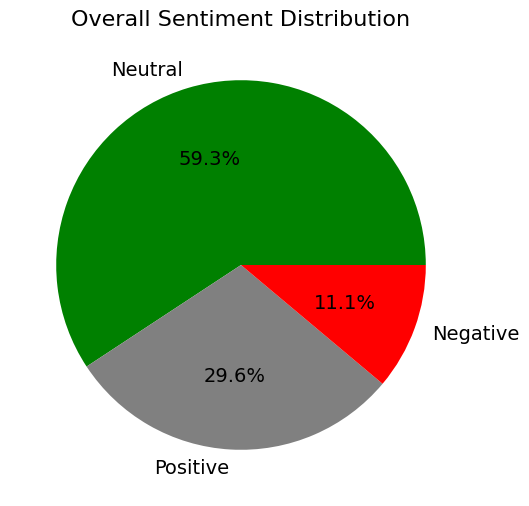

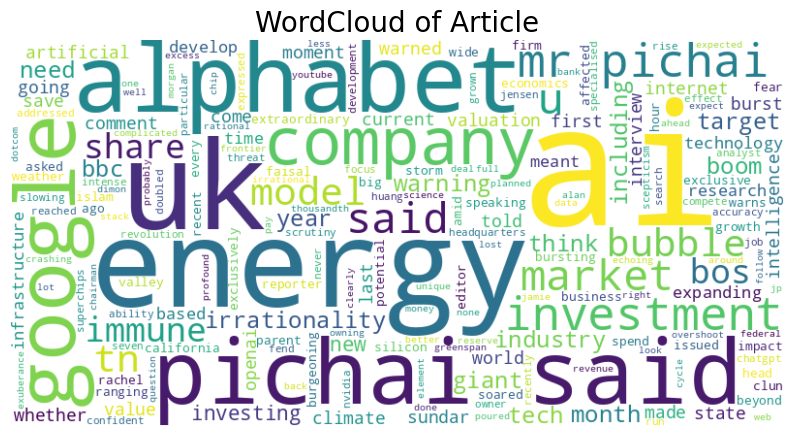

In [27]:

# Overall sentiment pie chart

sent_counts = sent_df['Sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%', colors=['green','grey','red'], textprops={'fontsize':14})
plt.title('Overall Sentiment Distribution', fontsize=16)
plt.show()


# WordCloud of cleaned text

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cleaned)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Article', fontsize=20)
plt.show()


## 2. Multi-Article Scraper

In [32]:
from newspaper import Article
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud


# NLTK setup

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# List of BBC URLs
urls = [
    "https://www.bbc.com/news/articles/cdjr4gk7v38o",
    "https://www.bbc.com/travel/article/20251114-the-best-christmas-market-in-europe",
    "https://www.bbc.com/news/articles/c4g311jn1m9o",
    "https://www.bbc.com/news/articles/crklvx2n7rzo",
    "https://www.bbc.com/news/articles/cvgwyyd8l58o"
]


# 1. Download and combine all articles

all_text = ""
headlines = []
authors_list = []
publish_dates = []

for url in urls:
    article = Article(url)
    article.download()
    article.parse()
    article.nlp()  # optional summary/keywords

    all_text += article.text + "\n"
    headlines.append(article.title)
    authors_list.append(article.authors)
    publish_dates.append(article.publish_date)

print("----- Headlines -----")
for i, h in enumerate(headlines):
    print(f"{i+1}. {h}")

print("\nTotal combined text length:", len(all_text), "characters")
print("\nFirst 5 lines of combined text:\n", "\n".join(all_text.split("\n")[:5]))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


----- Headlines -----
1. So long, plastic wet wipes - but should we be flushing the new ones?
2. Seven countries, one winner: The best Christmas market in Europe
3. A Chinese firm bought an insurer for CIA agents - part of Beijing's trillion dollar spending spree
4. China and Japan in escalating spat over Taiwan: What to know
5. Zelensky vows energy sector overhaul after $100m corruption scandal

Total combined text length: 24696 characters

First 5 lines of combined text:
 So long, plastic wet wipes - but should we be flushing the new ones?

6 hours ago Share Save Jonah Fisher Environment correspondent Share Save

Jonah Fisher/BBC Grant Mitchell from Severn Trent Water says every day 10 tonnes of wet wipes is removed from sewage at Minworth Wastewater Treatment works


In [33]:
# 2. Clean text

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r'[^a-z\s]', ' ', txt)
    tokens = txt.split()
    tokens = [t for t in tokens if t not in stop]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

cleaned = clean_text(all_text)
print("\nCleaned text length:", len(cleaned), "characters")


# 3. DataFrame of words

words = cleaned.split()
df = pd.DataFrame(words, columns=['Word'])
print("\n----- DataFrame info -----")
print(df.info())
print(df.head())
print("\nDataFrame shape:", df.shape)


Cleaned text length: 17122 characters

----- DataFrame info -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2360 entries, 0 to 2359
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Word    2360 non-null   object
dtypes: object(1)
memory usage: 18.6+ KB
None
       Word
0      long
1   plastic
2       wet
3      wipe
4  flushing

DataFrame shape: (2360, 1)


In [34]:
# 4. Sentiment Analysis per sentence

sentences = nltk.sent_tokenize(all_text)
sentiment_list = []

for sent in sentences:
    blob = TextBlob(sent)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    sentiment_list.append({'Sentence': sent, 'Polarity': polarity, 'Sentiment': sentiment})

sent_df = pd.DataFrame(sentiment_list)
print("\n----- Sentiment per sentence -----")
print(sent_df.head())
print("\nTotal number of sentences:", len(sent_df))


----- Sentiment per sentence -----
                                            Sentence  Polarity Sentiment
0  So long, plastic wet wipes - but should we be ... -0.004545   Neutral
1  6 hours ago Share Save Jonah Fisher Environmen... -0.062500   Neutral
2  The new rules will come into force in 2027 and...  0.136364  Positive
3  Plastic wipes don't disintegrate when flushed ... -0.029630   Neutral
4  Most of the wipes that are sold in the UK are ...  0.500000  Positive

Total number of sentences: 172


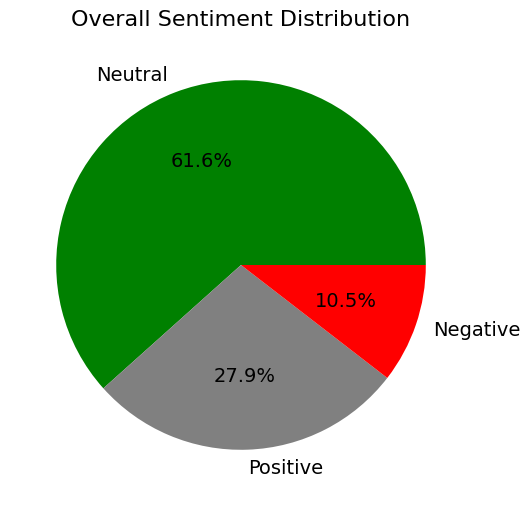

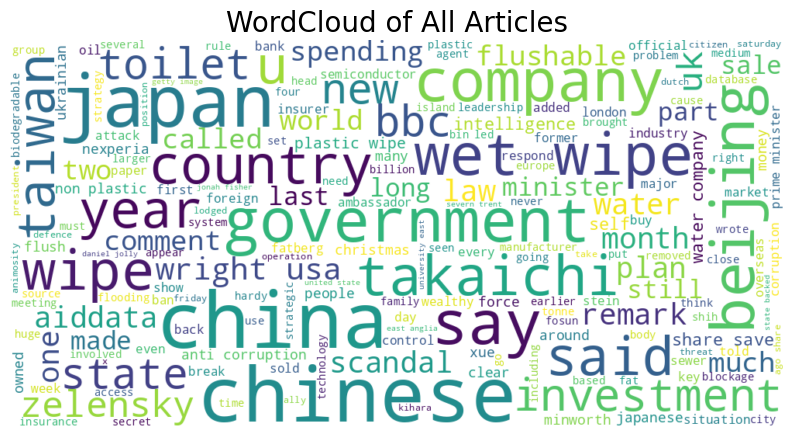

In [35]:

# 5. Overall sentiment pie chart

sent_counts = sent_df['Sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%',
        colors=['green','grey','red'], textprops={'fontsize':14})
plt.title('Overall Sentiment Distribution', fontsize=16)
plt.show()

# 6. WordCloud of cleaned text

wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      max_font_size=100, min_font_size=10).generate(cleaned)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of All Articles', fontsize=20)
plt.show()


# RoBERTa: A Robustly Optimized BERT Approach

## Overview
RoBERTa (Robustly Optimized BERT Approach) is an improved and optimized version of the BERT transformer model.  
It was introduced in 2019 by Facebook AI Research (FAIR), now Meta AI, in collaboration with the University of Washington.  
The model retains the same architecture as BERT but introduces significant training improvements that lead to stronger downstream performance.

## Who Built RoBERTa?
- Organization: Facebook AI Research (FAIR) and University of Washington  
- Year: 2019  
- Paper Title: **"RoBERTa: A Robustly Optimized BERT Pretraining Approach"**  
- Authors: Yinhan Liu, Myle Ott, Naman Goyal, Jingfei Du, Mandar Joshi, Danqi Chen, Omer Levy, Mike Lewis, Luke Zettlemoyer, Veselin Stoyanov  

## Why RoBERTa Was Created
RoBERTa was developed to re-evaluate BERT's original training strategy.  
The authors demonstrated that BERT was *under-trained*, and its performance could be improved without changing the architecture.  
RoBERTa modifies the training procedure in several key ways:

- Trains on much larger datasets  
- Removes Next Sentence Prediction (NSP)  
- Uses dynamic masking instead of static masking  
- Trains for significantly more steps  
- Uses larger batch sizes  
- Uses longer sequences throughout training  

These modifications lead to a stronger and more robust language model.

## Architecture and Network Configuration

RoBERTa uses the same transformer encoder architecture as BERT.  
There are two widely used versions: RoBERTa-base and RoBERTa-large.

### RoBERTa-base Configuration
- Layers (Transformer blocks): 12  
- Hidden size: 768  
- Number of attention heads: 12  
- Intermediate feed-forward size: 3072  
- Maximum sequence length: 512 tokens  
- Total parameters: ~125 million  

### RoBERTa-large Configuration
- Layers: 24  
- Hidden size: 1024  
- Number of attention heads: 16  
- Intermediate feed-forward size: 4096  
- Maximum sequence length: 512 tokens  
- Total parameters: ~355 million  

## Key Improvements Over BERT
RoBERTa keeps the architecture the same but improves the training setup:

1. Trained on more than 160 GB of text (10 times more than BERT).  
2. Removes Next Sentence Prediction (NSP), which was not beneficial.  
3. Uses dynamic masking where mask positions change every epoch.  
4. Trains for longer with larger batch sizes.  
5. Uses full-length sequences (512 tokens) from the beginning of training.  
6. Optimizes learning rate schedules and training hyperparameters.

## Training Data Used
RoBERTa was trained on the following large-scale corpora:

- BookCorpus  
- English Wikipedia  
- CC-News  
- OpenWebText  
- Stories dataset  

## Performance
RoBERTa achieved state-of-the-art results in 2019 on several major NLP benchmarks, such as:

- GLUE  
- SQuAD  
- RACE  

The model influenced several later transformer models and remains popular for sentiment analysis, text classification, and general NLP tasks.

## Conclusion
RoBERTa demonstrated that BERT's architecture was already powerful and that improving training methodology leads to substantial gains.  
By scaling data, batch size, training duration, and removing unnecessary objectives like NSP, RoBERTa became one of the strongest transformer-based language models of its time.


In [36]:
from newspaper import Article
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
# BBC URLs

urls = [
   "https://www.bbc.com/news/articles/cdjr4gk7v38o",
    "https://www.bbc.com/travel/article/20251114-the-best-christmas-market-in-europe",
    "https://www.bbc.com/news/articles/c4g311jn1m9o",
    "https://www.bbc.com/news/articles/crklvx2n7rzo",
    "https://www.bbc.com/news/articles/cvgwyyd8l58o"
]

In [38]:
# EXTRACT TEXT FROM ALL ARTICLES

all_text = ""
headlines = []
authors_list = []
publish_dates = []

for url in urls:
    article = Article(url)
    article.download()
    article.parse()
    article.nlp()

    all_text += article.text + "\n"
    headlines.append(article.title)
    authors_list.append(article.authors)
    publish_dates.append(article.publish_date)

print("Total combined text length:", len(all_text), "characters")

Total combined text length: 24696 characters


In [39]:
# SPLIT COMBINED TEXT INTO SENTENCES
sentences = nltk.sent_tokenize(all_text)
print("Total sentences extracted:", len(sentences))

Total sentences extracted: 172


In [40]:
# LOAD RoBERTa MODEL (TRUE 3-CLASS)

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

labels = ["Negative", "Neutral", "Positive"]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [41]:
# RUN SENTIMENT ANALYSIS

sentiment_rows = []

for s in sentences:
    inputs = tokenizer(s, return_tensors="pt", truncation=True)
    outputs = model(**inputs)
    scores = torch.softmax(outputs.logits, dim=1).detach().numpy()[0]

    sentiment_rows.append({
        "Sentence": s,
        "Negative_Score": float(scores[0]),
        "Neutral_Score": float(scores[1]),
        "Positive_Score": float(scores[2]),
        "Sentiment": labels[scores.argmax()]
    })

df_roberta = pd.DataFrame(sentiment_rows)


# SHOW SAMPLE OUTPUT

print(df_roberta.head(10))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


                                            Sentence  Negative_Score  \
0  So long, plastic wet wipes - but should we be ...        0.591511   
1  6 hours ago Share Save Jonah Fisher Environmen...        0.085846   
2  The new rules will come into force in 2027 and...        0.005177   
3  Plastic wipes don't disintegrate when flushed ...        0.567775   
4  Most of the wipes that are sold in the UK are ...        0.520223   
5  The wet wipe manufacturers contacted by the BB...        0.021462   
6  PA Media Last month, this massive fatberg was ...        0.359032   
7  Just last month a massive stinking lump of wet...        0.824176   
8  It weighed the same as eight double-decker bus...        0.497554   
9  The market for wet wipes has been growing stea...        0.082446   

   Neutral_Score  Positive_Score Sentiment  
0       0.367524        0.040965  Negative  
1       0.879867        0.034287   Neutral  
2       0.824394        0.170429   Neutral  
3       0.403535        0.0

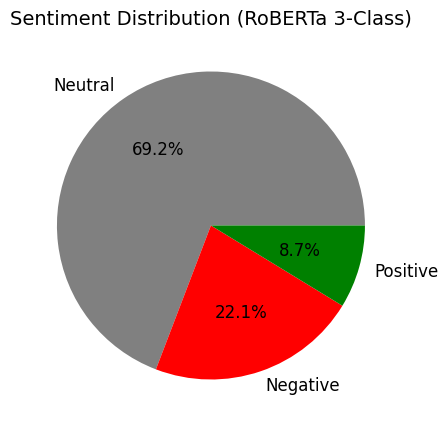

In [42]:
sent_counts = df_roberta["Sentiment"].value_counts()

colors = {
    "Positive": "green",
    "Neutral": "grey",
    "Negative": "red"
}

plt.figure(figsize=(5, 5))  # smaller chart
plt.pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=[colors[s] for s in sent_counts.index],
    textprops={'fontsize': 12}
)
plt.title("Sentiment Distribution (RoBERTa 3-Class)", fontsize=14)
plt.show()
